## 1 . Carga y Análisis Exploratorio

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>1.1. Carga y Estructura:</h4>
</div>

In [1]:
# Importaciones necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, precision_score, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

In [2]:
#Carga del dataset
df = pd.read_csv('cloudsync_churn_data.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   api_response_time_ms       3000 non-null   float64
 1   monthly_ip_variation       2850 non-null   float64
 2   avg_network_latency        3000 non-null   float64
 3   unique_active_devices      3000 non-null   int64  
 4   days_since_app_update      3000 non-null   int64  
 5   internal_engagement_score  3000 non-null   float64
 6   nps_satisfaction_score     3000 non-null   int64  
 7   monthly_usage_frequency    3000 non-null   int64  
 8   open_support_tickets       3000 non-null   int64  
 9   promotional_discount_pct   3000 non-null   int64  
 10  current_subscription_tier  2850 non-null   float64
 11  customer_age               3000 non-null   int64  
 12  declared_income            3000 non-null   float64
 13  virtual_wallet_balance     3000 non-null   float

,api_response_time_ms,monthly_ip_variation,avg_network_latency,unique_active_devices,days_since_app_update,internal_engagement_score,nps_satisfaction_score,monthly_usage_frequency,open_support_tickets,promotional_discount_pct,...,customer_age,declared_income,virtual_wallet_balance,email_open_rate,newsletter_clicks,historical_purchases,account_age_days,payment_method,assigned_server_region,subscription_status
0,18.615127,7.0,30.069944,8,7,22.606118,2,20,1,0,...,55,50058.41,31.70,29.800941,3,5,533,Bank Transfer,Region_16,0
1,57.214215,NaN,109.410786,8,16,79.154274,10,91,0,10,...,21,62994.41,104.73,42.198697,6,2,561,PayPal,Region_39,2
2,32.247088,7.0,55.214023,7,10,74.514592,10,43,0,5,...,20,52248.29,16.54,14.623551,2,1,106,Credit Card,Region_11,1
3,7.054161,2.0,13.777965,3,14,20.282166,1,59,0,10,...,56,34111.91,0.00,12.529304,0,2,562,Bank Transfer,Region_14,0
4,19.782102,1.0,32.648796,3,8,70.395642,0,70,3,0,...,24,49210.62,0.00,20.658356,1,1,1936,PayPal,Region_07,0


In [3]:
df.describe()

,api_response_time_ms,monthly_ip_variation,avg_network_latency,unique_active_devices,days_since_app_update,internal_engagement_score,nps_satisfaction_score,monthly_usage_frequency,open_support_tickets,promotional_discount_pct,current_subscription_tier,customer_age,declared_income,virtual_wallet_balance,email_open_rate,newsletter_clicks,historical_purchases,account_age_days,subscription_status
count,3000.000000,2850.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,2850.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,23.697129,3.838596,37.041505,4.193000,12.644000,47.219704,4.937333,50.830333,1.083000,10.851667,2.090175,35.475667,54572.092013,58.985223,28.436146,2.406667,2.992333,1019.233000,0.507000
std,30.432795,3.096084,26.617488,2.357033,6.763075,25.285813,4.087988,29.109907,1.500287,17.276163,1.183101,10.372557,15606.170797,88.830407,16.173277,2.469275,1.725669,571.400716,0.669901
min,3.427495,1.000000,1.000000,1.000000,0.000000,20.076168,0.000000,0.000000,0.000000,0.000000,1.000000,18.000000,12000.000000,0.000000,0.728125,0.000000,0.000000,36.000000,0.000000
25%,11.085390,2.000000,19.876595,3.000000,9.000000,20.807521,1.000000,26.000000,0.000000,0.000000,1.000000,28.000000,43657.712500,0.000000,16.086679,0.000000,2.000000,526.000000,0.000000
50%,16.446224,3.000000,29.747156,4.000000,12.000000,70.107600,2.000000,52.000000,1.000000,5.000000,2.000000,34.000000,54047.545000,18.180000,26.322919,2.000000,3.000000,1004.500000,0.000000
75%,26.438698,5.000000,45.835180,5.000000,16.000000,70.880352,9.000000,77.000000,2.000000,15.000000,3.000000,42.000000,64834.170000,86.155000,38.816306,4.000000,4.000000,1520.250000,1.000000
max,850.323118,20.000000,245.947726,15.000000,120.000000,100.000000,10.000000,99.000000,13.000000,95.000000,5.000000,87.000000,114573.550000,694.760000,92.726462,14.000000,12.000000,2019.000000,2.000000


In [4]:
df.isnull().sum() 

api_response_time_ms           0
monthly_ip_variation         150
avg_network_latency            0
unique_active_devices          0
days_since_app_update          0
internal_engagement_score      0
nps_satisfaction_score         0
monthly_usage_frequency        0
open_support_tickets           0
promotional_discount_pct       0
current_subscription_tier    150
customer_age                   0
declared_income                0
virtual_wallet_balance         0
email_open_rate                0
newsletter_clicks              0
historical_purchases           0
account_age_days               0
payment_method                 0
assigned_server_region         0
subscription_status            0
dtype: int64

In [5]:
#Imputamos con la mediana (son valores numéricos y es robusta a outliers)
df['monthly_ip_variation'] = df['monthly_ip_variation'].fillna(df['monthly_ip_variation'].median())
df['current_subscription_tier'] = df['current_subscription_tier'].fillna(df['current_subscription_tier'].median())
print(df.isnull().sum())
df.describe()

api_response_time_ms         0
monthly_ip_variation         0
avg_network_latency          0
unique_active_devices        0
days_since_app_update        0
internal_engagement_score    0
nps_satisfaction_score       0
monthly_usage_frequency      0
open_support_tickets         0
promotional_discount_pct     0
current_subscription_tier    0
customer_age                 0
declared_income              0
virtual_wallet_balance       0
email_open_rate              0
newsletter_clicks            0
historical_purchases         0
account_age_days             0
payment_method               0
assigned_server_region       0
subscription_status          0
dtype: int64


,api_response_time_ms,monthly_ip_variation,avg_network_latency,unique_active_devices,days_since_app_update,internal_engagement_score,nps_satisfaction_score,monthly_usage_frequency,open_support_tickets,promotional_discount_pct,current_subscription_tier,customer_age,declared_income,virtual_wallet_balance,email_open_rate,newsletter_clicks,historical_purchases,account_age_days,subscription_status
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,23.697129,3.796667,37.041505,4.193000,12.644000,47.219704,4.937333,50.830333,1.083000,10.851667,2.085667,35.475667,54572.092013,58.985223,28.436146,2.406667,2.992333,1019.233000,0.507000
std,30.432795,3.023194,26.617488,2.357033,6.763075,25.285813,4.087988,29.109907,1.500287,17.276163,1.153302,10.372557,15606.170797,88.830407,16.173277,2.469275,1.725669,571.400716,0.669901
min,3.427495,1.000000,1.000000,1.000000,0.000000,20.076168,0.000000,0.000000,0.000000,0.000000,1.000000,18.000000,12000.000000,0.000000,0.728125,0.000000,0.000000,36.000000,0.000000
25%,11.085390,2.000000,19.876595,3.000000,9.000000,20.807521,1.000000,26.000000,0.000000,0.000000,1.000000,28.000000,43657.712500,0.000000,16.086679,0.000000,2.000000,526.000000,0.000000
50%,16.446224,3.000000,29.747156,4.000000,12.000000,70.107600,2.000000,52.000000,1.000000,5.000000,2.000000,34.000000,54047.545000,18.180000,26.322919,2.000000,3.000000,1004.500000,0.000000
75%,26.438698,5.000000,45.835180,5.000000,16.000000,70.880352,9.000000,77.000000,2.000000,15.000000,3.000000,42.000000,64834.170000,86.155000,38.816306,4.000000,4.000000,1520.250000,1.000000
max,850.323118,20.000000,245.947726,15.000000,120.000000,100.000000,10.000000,99.000000,13.000000,95.000000,5.000000,87.000000,114573.550000,694.760000,92.726462,14.000000,12.000000,2019.000000,2.000000


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones:</h4> 
Del análisis de los datos podemos ver que tenemos 3000 entradas con 21 columnas, en las que podemos observar:

* 150 valores nulos en monthly_ip_variation y otros 150 en current_subscription_tier.
* Tenemos 11 variables int, 8 float (con decimales) y dos object (variables categóricas). La variable objetivo, subscription_status, vemos que está desviada porque la media es 0.507 y su Q3 es 1 pero tanto el Q1 como Q2 son 0.
* Otros valores llamativos por tener outliers, como api_response_time_ms (tiene media 23.7 y std 30.4 pero max 850 ), avg_network_latency (con media 37 y max 245), promotional_discount_pct (media 10.85 y max 95), virtual_wallet_balance (media 58.98 y max 694.76) y email_open_rate (media 28.4 y max 92.7). Estos valores los dejamos ya que creo que son valores reales (descuentos altos y tiempo de respuestas muy lentos en ocasiones) y eliminarlos podría causar una perdida de sensibilidad del modelo a razones reales por las cuales los usuarios deciden cancelar o no. 
* Por el contrario, hay variables con poca variabilidad, como unique_active_devices que va de 1-15 pero en Q3 es 5 (desviado hacia abajo), historical purchases, también mayoría del 1-4 siendo el máximo 12, o newsletter_clicks (de 0-4 siendo máximo 14)


</div>


<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>1.2. Análisis Exploratorio (EDA) Comparativo con I.A.:</h4>
    
* Utilizamos una herramienta de IA generativa para que nos describa cuáles suelen ser, **según la teoría del sector SaaS**, los indicadores más comunes que predicen el abandono (*churn*) de un cliente.
</div>

### Respuesta resumida de la IA: 

En SaaS, los indicadores que mejor predicen el churn suelen agruparse en 5 bloques:

**1. Caída de uso**

* Menos logins o sesiones
* Menor frecuencia o duración de uso
* Descenso del MAU/WAU

**2. Pérdida de hábito**

* El usuario entra de forma irregular
* Cada vez pasan más días entre usos
* El producto deja de ser parte de su rutina

**3. Baja activación de valor**

* No llega al “aha moment”
* No usa las funcionalidades clave del producto
* Se queda en un uso superficial

**4. Engagement decreciente**

* Menos acciones dentro del producto
* Uso limitado a una sola feature
* Menor interacción progresiva con el tiempo

**5. Señales de negocio / fricción**

* Downgrade o problemas de pago
* Quejas o tickets de soporte
* Reducción de uso en equipos (B2B)

En esencia: cuando baja el uso, se pierde el hábito y no se alcanza valor real, el churn es altamente probable.


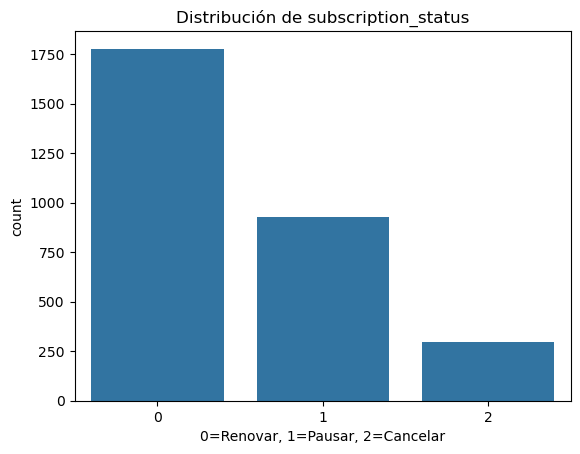

subscription_status
0    1777
1     925
2     298
Name: count, dtype: int64


In [6]:
#Vamos a ver la distribución de la variable objetivo porque esperamos desequilibrio
sns.countplot(x='subscription_status', data=df)
plt.title('Distribución de subscription_status')
plt.xlabel('0=Renovar, 1=Pausar, 2=Cancelar')
plt.show()
#Vemos cuales son los datos exactos
print(df['subscription_status'].value_counts())

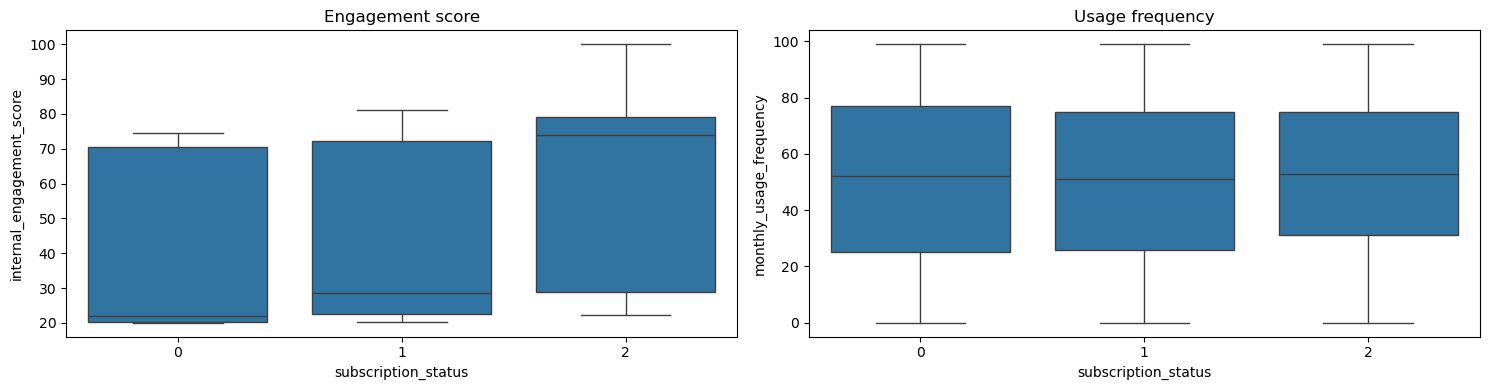

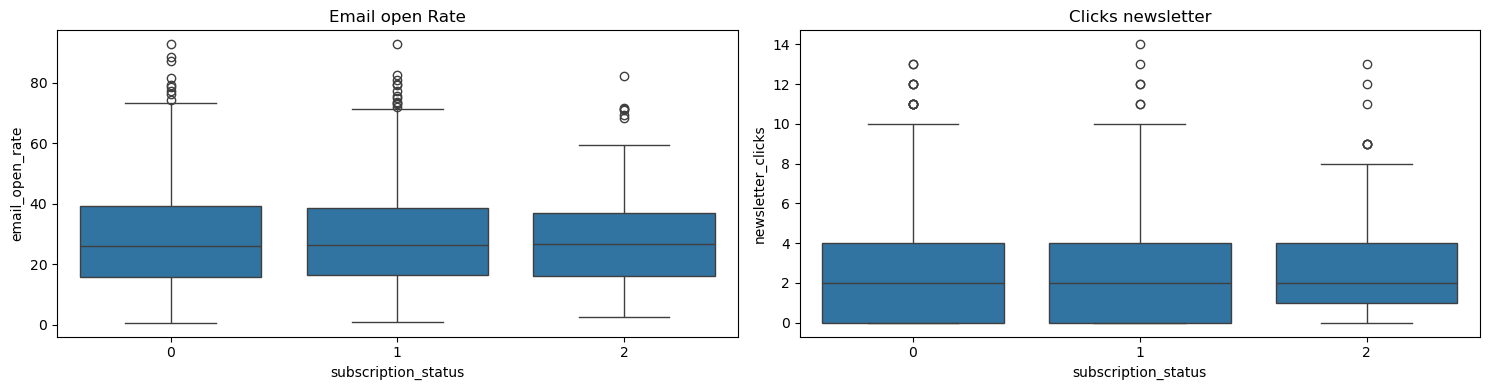

In [7]:
#Uno de los principales predictores de churn según la Ia es el uso y el engagement
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.boxplot(x='subscription_status', y='internal_engagement_score', data=df, ax=axes[0])
axes[0].set_title('Engagement score')
sns.boxplot(x='subscription_status', y='monthly_usage_frequency', data=df, ax=axes[1])
axes[1].set_title('Usage frequency')
plt.tight_layout()
plt.show()

#También vemos si influye la apertura de correos y de newsletter
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.boxplot(x='subscription_status', y='email_open_rate', data=df, ax=axes[0])
axes[0].set_title('Email open Rate')
sns.boxplot(x='subscription_status', y='newsletter_clicks', data=df, ax=axes[1])
axes[1].set_title('Clicks newsletter')
plt.tight_layout()
plt.show()

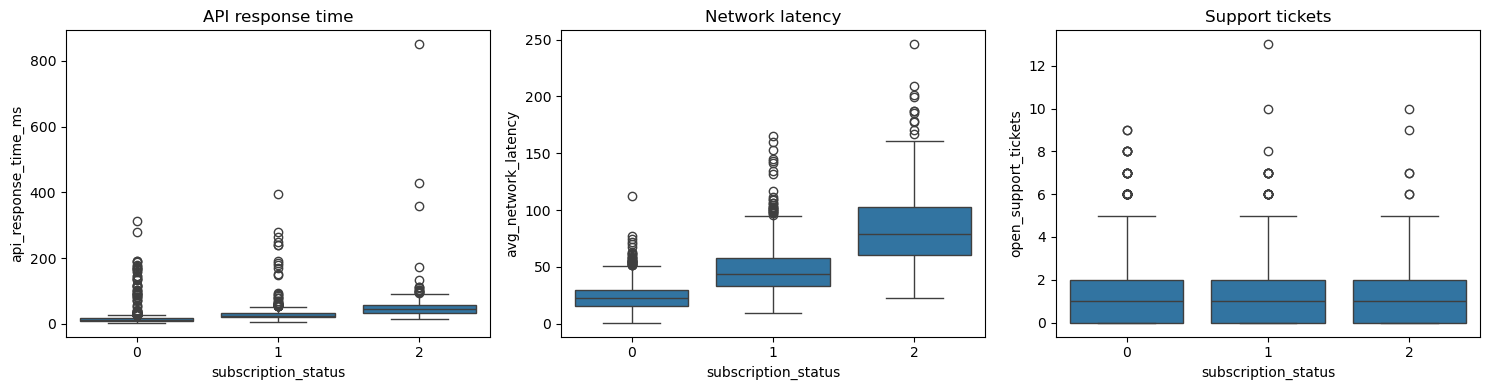

In [8]:
#La latencia alta, el tiempo de respuesta y el número de tickets a soporte afectan ya que al fallar
#aplicación puede disminuir su uso por lo que comprobamos si tienen relación con la cancelación
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(x='subscription_status', y='api_response_time_ms', data=df, ax=axes[0])
axes[0].set_title('API response time')

sns.boxplot(x='subscription_status', y='avg_network_latency', data=df, ax=axes[1])
axes[1].set_title('Network latency')

sns.boxplot(x='subscription_status', y='open_support_tickets', data=df, ax=axes[2])
axes[2].set_title('Support tickets')

plt.tight_layout()
plt.show()

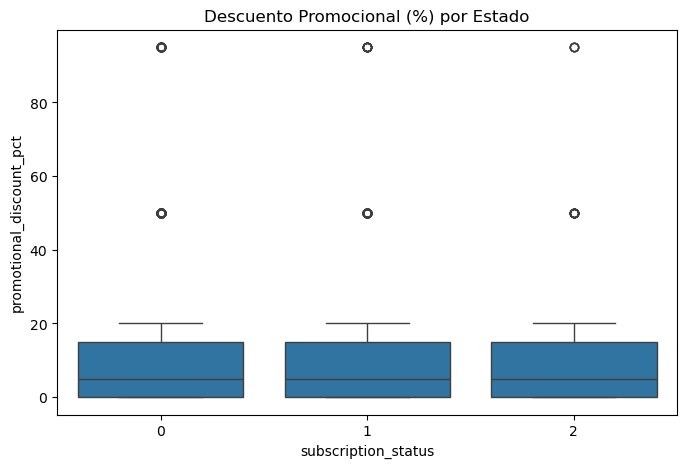

In [9]:
#Miramos si los descuentos afectan al abandono
plt.figure(figsize=(8,5))
sns.boxplot(x='subscription_status', y='promotional_discount_pct', data=df)
plt.title('Descuento Promocional (%) por Estado')
plt.show()

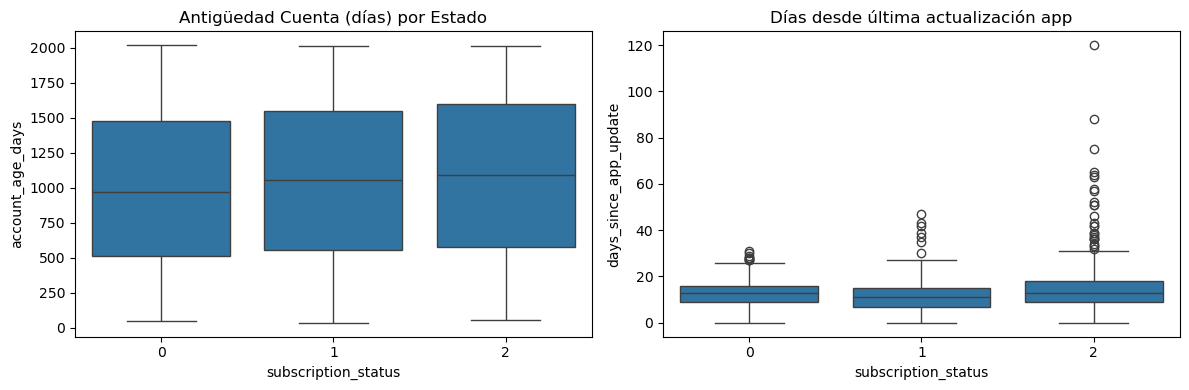

In [10]:
#Analizamos si cuenta la antiguedad del cliente
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='subscription_status', y='account_age_days', data=df, ax=axes[0])
axes[0].set_title('Antigüedad Cuenta (días) por Estado')
#y la última actualización de la aplicación
sns.boxplot(x='subscription_status', y='days_since_app_update', data=df, ax=axes[1])
axes[1].set_title('Días desde última actualización app')

plt.tight_layout()
plt.show()

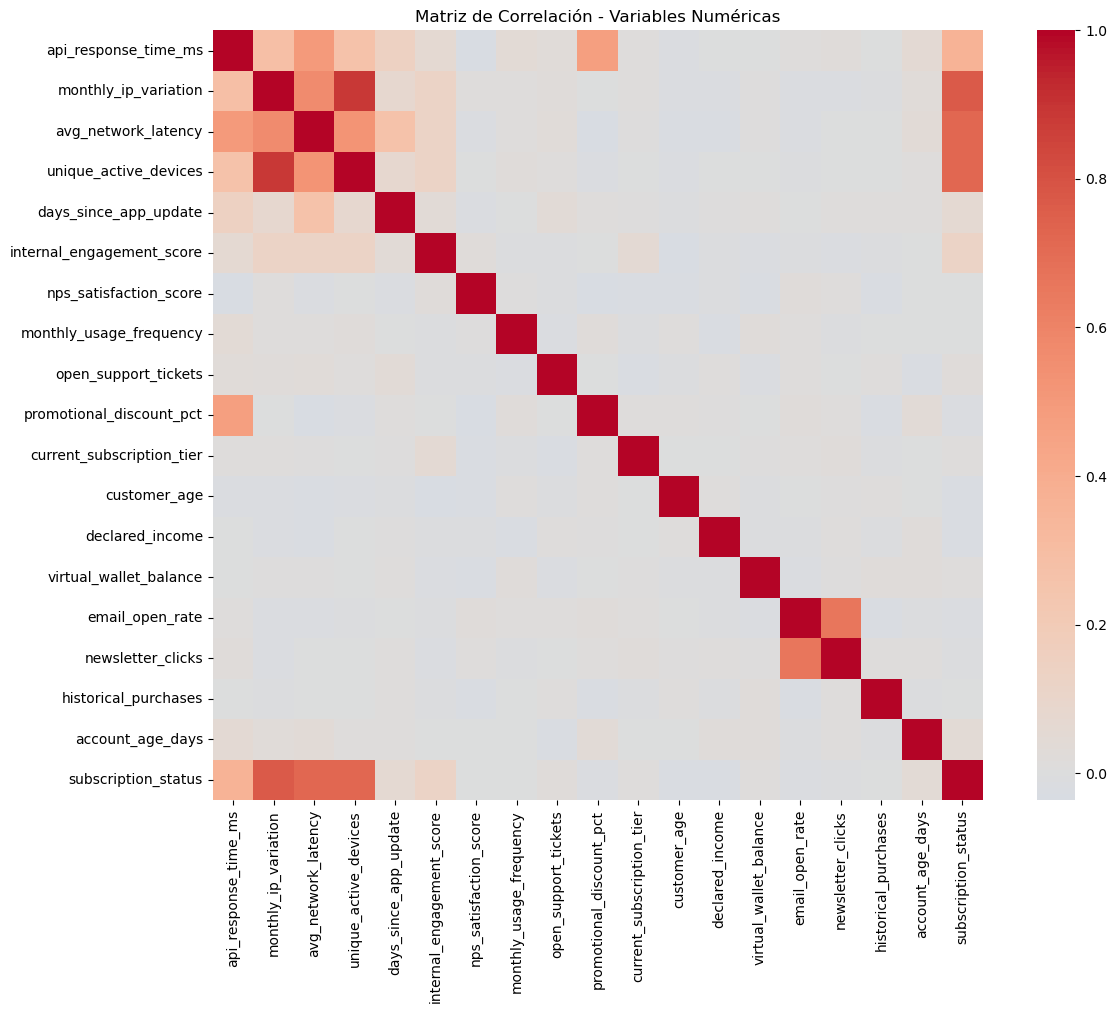

                     var1                   var2  correlacion
19   monthly_ip_variation  unique_active_devices     0.885146
34   monthly_ip_variation    subscription_status     0.770745
50    avg_network_latency    subscription_status     0.719279
65  unique_active_devices    subscription_status     0.718942


In [11]:
#Calculamos la matriz de correlación de las numéricas
numericas = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numericas].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.show()

#Mostramos correlaciones más altas (> 0.7) por posible multicolenialidad
high_corr = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = high_corr.stack().reset_index()
high_corr.columns = ['var1', 'var2', 'correlacion']
high_corr = high_corr[abs(high_corr['correlacion']) > 0.7]
print(high_corr)

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones:</h4>  

* Hay una gran mayoría que renueva, 1777. También hay bastantes pausas, 925, siendo más de la mitad de los que renuevan y las cancelaciones de nuestros datos son de 298.

* El engagement si que influye en las cancelaciones pero no influye demasiado en las pausas (es muy ligeramente superior el boxplot que el de renovar), mientras que la frecuencia de uso no influye en nignuna. Lo mismo ocurre con el uso de servicios como el mail o la newsletter, que apenas varían entre el estatus de la subscripción.

* Tanto el tiempo de respuesta de la api como en especial la latencia de la red afectan a las pausas y a las cancelaciones. El número de tickets no afecta mucho, con incluso algunos outliers más en las pausas que en las cancelaciones. 

* Los descuentos promocionales no afectan ni a causas ni a cancelaciones

* La antigüedad del cliente no afecta, pero si que hay relación entre el tiempo que hace desde la última vez que se actualizó la aplicación y las pausas y cancelaciones (en especial en estas últimas).

* Las variable más correlacionadas son monthly_ip_variation y unique_active_devices     (0.885) , monthly_ip_variation  y  subscription_status (0.771), avg_network_latency y subscription_status (0.719) y unique_active_devices y  subscription_status (0.718). No eliminaré unique_active_devices porque los modelos principales que vamos a utilizar (random forest y gradient boosting) son robustos a la multicolinealidad y ambas tienen una correlacion muy alta con la variable objetivo por lo que en este caso las dejaría porque podría causar una pérdida de información relevante.


</div>

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>1.3. Análisis Crítico de Evidencia y comparación con IA:</h4>
</div>

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones:</h4>  
La IA dió el bajo engagement y la caída en la frecuencia de uso como predictores muy importantes de churn en el sector SaaS. Pero contrastándolo con los datos de CloudSync, estas variables no son relevantes para determinar si los clientes cancelan o no ya que apenas varía el engagement score (que es incluso ligeramente superior) frente a los que renuevan y la frecuencia de uso mensual es prácticamente igual entre todas las clases. 
    
También mencionaba el soporte y la quejas de la aplicación como relevantes por ser indicadores del funcionamiento de la app. Curiosamente en nuestros datos los tickets se mantienen bastante similares entres los que cancelan y renuevan, mientras que lo que si varía e influye es el rendimiento de la aplicación (la respuesta de la api y la latencia de la red), que aunque también lo mencionó, le dio como una importancia menor. Esto puede indicar que hay mala calidad de la comuncicación entre cliente y proveedor ya que los que cancelan no tienen un aumento de tickets pero sí que tienen mayores problemas técnicos, que puede deberse a factores que desconocemos (mala gestión de los tickets existentes, burocracia interna pesada, etc) pero que en nuestro caso no nos permite utilizar la variable de tickets abiertos como predictor de nuestro modelo. 

La última actualización de la aplicación también influye en las cancelaciones, siendo mayor en las cancelaciones y en las pausas, que puede ser un signo del desuso de la apliación, lo que no dice explícitamente la IA pero se puede relacionar con la disminución del uso del producto. 

Por otro lado, encontramos desafíos, como el desequilibrio de la variable objetivo subscription_status donde renovar tiene mucho mas peso que pausar y aún mucho mas que cancelar, que podría hacer que el modelo de más peso a predecir renovar y aun asi daría una accuracy buena pero no estaría siendo buen predictor de lo que realmente nos interesa detectar que son las cancelaciones.

También hemos encontrado potencial multicolinealidad en concreto entre monthly_ip_variation y unique_active_devices que puede crear redundancia en la información y outliers, que mencionamos en el análisis y pueden distorsionar nuestros datos.
</div>

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>1.4. Preparación y Justificación de Datos:</h4></div>

In [12]:
#Los nulos los imputamos en el 1.1, lo comprobamos
print(df.isnull().sum()) 

#Separamos x e y
x = df.drop('subscription_status', axis=1)
y = df['subscription_status']

#Dividimos train y test estratificando
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y 
)
print(f"Tamaño train: {X_train.shape[0]}")
print(f"Tamaño test: {X_test.shape[0]}")

#Separamos las columnas numéricas y categóricas
numericas = x.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = x.select_dtypes(include=['object']).columns.tolist()

#Creamos el encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
#Entrenamos el encoder (aprende qué categorías existen en train)
encoder.fit(X_train[categoricas])

#Transformamos X_train a numérica
X_train_encoded = encoder.transform(X_train[categoricas])
#Con esas columnas transformamos test
X_test_encoded = encoder.transform(X_test[categoricas])

#Obtenemos los nombres de las columnas creadas
encoded_cols = encoder.get_feature_names_out(categoricas)
#Y lo convertimos a DataFrame (para poder unirlo con el resto de datos)
X_train_encoded_df = pd.DataFrame(
    X_train_encoded, 
    columns=encoded_cols, 
    index=X_train.index  # Mantiene los mismos índices que X_train
)
X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoded_cols,
    index=X_test.index
)

#Reemplazamos las columnas categóricas originales por las codificadas
X_train = X_train.drop(columns=categoricas).join(X_train_encoded_df)
X_test = X_test.drop(columns=categoricas).join(X_test_encoded_df)

#Y estandarizamos para las numéricas
scaler = StandardScaler()
X_train[numericas] = scaler.fit_transform(X_train[numericas])  
X_test[numericas] = scaler.transform(X_test[numericas])

print(f"\nX_train shape final: {X_train.shape}")
print(f"X_test shape final: {X_test.shape}")

api_response_time_ms         0
monthly_ip_variation         0
avg_network_latency          0
unique_active_devices        0
days_since_app_update        0
internal_engagement_score    0
nps_satisfaction_score       0
monthly_usage_frequency      0
open_support_tickets         0
promotional_discount_pct     0
current_subscription_tier    0
customer_age                 0
declared_income              0
virtual_wallet_balance       0
email_open_rate              0
newsletter_clicks            0
historical_purchases         0
account_age_days             0
payment_method               0
assigned_server_region       0
subscription_status          0
dtype: int64
Tamaño train: 2400
Tamaño test: 600

X_train shape final: (2400, 62)
X_test shape final: (600, 62)


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones:</h4>  
    
Además de lo hecho en todos los apartados anteriores, en este hemos: 
    
* Quitamos los valores nulos de monthly_ip_variation y current_subscription_tier imputandolos con la mediana. 
* Dividimos el test en 80/20 como pide. Usamos stratify para mantener la proporción de las tres clases (Renovar, Pausar, Cancelar) en ambos conjuntos.
* Separamos en variables categóricas y numéricas para poder trabajar con ellas después por separado. Aplicamos el One-hot encoder a las variables categóricas para pasarlas a numéricas y entrenamos el encoder solo con X_train para evitar la contaminación con los datos del test y transformamos ambos con el encoder resultante. Luego reemplazamos en nuestros datasets estas columnas categóricas por las recien creadas y estandarizamos las variables numéricas
  
</div>

<div style="background-color: #d9edf7; color: #31708f; padding: 10px; border: 1px solid #bce8f1; border-radius: 4px;">
<h4>1.5. Análisis final:</h4>
</div>

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones:</h4>  
Utilicé chatgpt. Empecé haciéndole directamente la pregunta que se hace en la tarea "explicame cuáles suelen ser, según la teoría del sector SaaS, los indicadores más comunes que predicen el abandono (churn)" pero su respuesta fue un poco ambigua. Luego la modifiqué añadiendo que me explicase el por qué de estos y me diera ejemplos y situaciones reales. Por último, le pedí que me lo resumiera para ponerlo aquí. 


Su respuesta no fue mala pero no acertó del todo en este caso ya que muchas de las cosas que dicen (como la importancia del engagemt en el abandono del producto o el volumen de quejas) no han sido relevantes para nuestro caso. Esto podría indicar que el conocimiento general o lo que se piensa que afecta a estas probelmáticas es erróneo y debería estudiarse más para mejorar las variables que realmente afectan. Vi este artículo (https://fastercapital.com/es/contenido/Tasa-de-abandono-de-Saas--Retencion-de-clientes-en-SaaS--una-guia-completa.html#Las-principales-causas-del-abandono-de-SaaS-y-c-mo-identificarlas) en el que reacalca que el producto puede no ser apropiado para el mercado o tener un mal servicio al cliente (podría relacionarse en nuestro caso con el tiempo desde la ultima actualización) y tambien este más práctico y de marketing (https://www.linkedin.com/pulse/por-qu%C3%A9-abandonan-los-usuarios-una-plataforma-saas-de-ram%C3%ADrez-hhnee/) en que habla de variables algo diferentes, aunque si que menciona que la percepción (baja) de valor del producto Saas puede ser una causa de churn. Esto en nuestro dataset podría tener sentido dado que nuestra variable descuentos (promotional_discount_pct) no muestra diferencias entre cancelar o renovar lo que indica que descuentos en el precio no hacen que los clientes se queden más lo que puede apoyar la teoria de que el valor percibido del servicio pesa mucho. Uno de los problemas es que estos factores pueden ser un poco difíciles de medir para el poroveedor.

</div>

## 2 . Entrenamiento y Evaluación de Modelos Base

In [29]:
#Modelo 1: Regresión Logística
modelo_lr = LogisticRegression(random_state=42, max_iter=1000)
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)
print("Regresión Logística:")
print(classification_report(y_test, y_pred_lr, target_names=['Renovar', 'Pausar', 'Cancelar']))

#Modelo 2: Árbol de Decisión
modelo_dt = DecisionTreeClassifier(random_state=42)
modelo_dt.fit(X_train, y_train)
y_pred_dt = modelo_dt.predict(X_test)
print("\nÁrbol de Decisión:")
print(classification_report(y_test, y_pred_dt, target_names=['Renovar', 'Pausar', 'Cancelar']))

#Modelo 3: KNN
modelo_knn = KNeighborsClassifier()
modelo_knn.fit(X_train, y_train)
y_pred_knn = modelo_knn.predict(X_test)
print("\nKNN:")
print(classification_report(y_test, y_pred_knn, target_names=['Renovar', 'Pausar', 'Cancelar']))

#Modelo 4: Naïve Bayes
modelo_nb = GaussianNB()
modelo_nb.fit(X_train, y_train)
y_pred_nb = modelo_nb.predict(X_test) 
print("\nNaïve Bayes:")
print(classification_report(y_test, y_pred_nb, target_names=['Renovar', 'Pausar', 'Cancelar']))

Regresión Logística:
              precision    recall  f1-score   support

     Renovar       0.91      0.94      0.92       355
      Pausar       0.83      0.75      0.78       185
    Cancelar       0.79      0.83      0.81        60

    accuracy                           0.87       600
   macro avg       0.84      0.84      0.84       600
weighted avg       0.87      0.87      0.87       600


Árbol de Decisión:
              precision    recall  f1-score   support

     Renovar       0.90      0.86      0.88       355
      Pausar       0.65      0.69      0.67       185
    Cancelar       0.61      0.65      0.63        60

    accuracy                           0.79       600
   macro avg       0.72      0.73      0.73       600
weighted avg       0.80      0.79      0.79       600


KNN:
              precision    recall  f1-score   support

     Renovar       0.81      0.94      0.87       355
      Pausar       0.68      0.55      0.61       185
    Cancelar       0.82     

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones y Análisis Crítico:</h4>
De los cuatro modelos base evaluados, la Regresión Logística obtiene el mejor rendimiento para la clase Cancelar con un recall de 0.83 y un F1 de 0.81. El Árbol de Decisión y KNN tienen rendimientos inferiores (recall 0.63 y 0.53 respectivamente). Naïve Bayes es el peor, con una precisión muy baja (0.33) para la clase Cancelar, lo que generaría muchas falsas alarmas.

En cuanto al accuracy global, la Regresión Logística también es la mejor (0.87), seguida del Árbol de Decisión (0.80), KNN (0.79) y Naïve Bayes (0.64). Sin embargo, como ya justifiqué, el accuracy no es la métrica principal para este problema.

La métrica más informativa para este problema es el recall de la clase Cancelar. El enunciado indica que el peor escenario es perder a un cliente que cancela (falso negativo), y que la empresa prefiere incurrir en falsas alarmas operativas (gastar 50€ en una intervención preventiva) antes que ignorar a un cliente a punto de cancelar (pérdida de 2000€). Por lo tanto, minimizar los falsos negativos (maximizar el recall) es la prioridad. El accuracy global no es informativo porque un modelo que predijera siempre "Renovar" tendría un 59% de accuracy pero 0% de recall para la clase Cancelar.

</div>

## 3 . Combinación paralela de clasificadores de base similar: Bagging

In [30]:
#Definimos los parámetros que vamos a buscar
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 'log2']
}
#Validación cruzada con 5 folds estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#Configuramos GridSearchCV 
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_rf,
    cv=cv,
    scoring='recall_macro', #usamos recall como métrica
    return_train_score=True, # para medir rendimiento en entrenamiento
    n_jobs=-1  #usa todos los procesadores para ir más rapido
)

grid_rf.fit(X_train, y_train)

#Vemos los resultados
print(f"\nMejores parámetros: {grid_rf.best_params_}")
print(f"Mejor recall macro medio (CV): {grid_rf.best_score_:.4f}")

#Desviación estándar de la mejor combinación
best_index = grid_rf.best_index_
best_std = grid_rf.cv_results_['std_test_score'][best_index]
print(f"Desviación estándar de la mejor combinación: ± {best_std:.4f}")

#Mostramos todas las combinaciones probadas
print("Todas las combinaciones probadas:")
results_df = pd.DataFrame(grid_rf.cv_results_)
for i in range(len(results_df)):
    params = results_df['params'][i]
    mean_score = results_df['mean_test_score'][i]
    std_score = results_df['std_test_score'][i]
    print(f"Params: {params}")
    print(f"  Recall macro medio: {mean_score:.4f} (± {std_score:.4f})")
    print("-"*40)


Mejores parámetros: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
Mejor recall macro medio (CV): 0.8019
Desviación estándar de la mejor combinación: ± 0.0152
Todas las combinaciones probadas:
Params: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}
  Recall macro medio: 0.7944 (± 0.0153)
----------------------------------------
Params: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
  Recall macro medio: 0.7943 (± 0.0133)
----------------------------------------
Params: {'max_depth': 10, 'max_features': 'log2', 'n_estimators': 100}
  Recall macro medio: 0.7813 (± 0.0111)
----------------------------------------
Params: {'max_depth': 10, 'max_features': 'log2', 'n_estimators': 200}
  Recall macro medio: 0.7802 (± 0.0082)
----------------------------------------
Params: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 100}
  Recall macro medio: 0.8004 (± 0.0142)
----------------------------------------
Params: {'max_depth': 20, 'm

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Análisis:</h4>  

* Hemos usado GridSearchCV  con validación cruzada con 5 folds. Como métrica hemos elegido el recall (recall_macro porque son 3: Renovar, Pausar, Cancelar). El modelo funciona mejor con los hiperparámetros 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100 con un recall medio de 0.8019. Si vemos los resultados de otras combinaciones vemos que con una profundidad de 20 ya se acerca bastante a este valor más optimo. También parece que sqrt funciona en general mejor que con el log2 para este modelo , siendo el segundo mejor 'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200 .
</div>

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones y Análisis Crítico:</h4>  

* Vemos que con el bagging aumenta el accuracy del modelo (0.89 frente a 0.87 que fue el mejor modelo anterior) e incluso ligeramente el recall general (de 0.84 a 0.85), pero disminuye el recall para la clase cancelaciones (era de 0.83 en refresion logística y e este es de 0.78) aumentando el de pausar (ya que al tener más peso le da más importancia en el random forest). Esto es negativo para nosotros ya que lo que más nos importa analizar son las cancelaciones.
* Las características más imporrtantes son api_response_time_ms en primer lugar con 0.1513, luego y muy parejas monthly_ip_variation (0.1433) y avg_network_latency (0.1428); después, internal_engagement_score (0.1185) y unique_active_devices (0.1150) y las siguientes ya son considerablemente menos importantes. Esto que se asemeja mucho a lo que vimos en el análisis exploratorio.

</div>

## 4 . Combinación paralela de clasificadores de base similar: Boosting

In [28]:
#Definimos los valores posibles de hiperparámetros
param_grid_gb = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7] #en boosting los árboles son más pequeños
}

#Validación cruzada estratificada con 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#GridSearch con recall_macro
grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=cv,
    scoring='recall_macro',
    n_jobs=-1
)
grid_gb.fit(X_train, y_train)

#Vemos los resultados
print(f"\nMejores parámetros: {grid_gb.best_params_}")
print(f"Mejor recall macro medio (CV): {grid_gb.best_score_:.4f}")

# Mostrar también la desviación estándar
best_index = grid_gb.best_index_
best_std = grid_gb.cv_results_['std_test_score'][best_index]
print(f"\nDesviación estándar de la mejor combinación: ± {best_std:.4f}")

#Mostrar todas las combinaciones
print("Todas las combinaciones probadas:")
results_df = pd.DataFrame(grid_gb.cv_results_)
for i in range(len(results_df)):
    params = results_df['params'][i]
    mean_score = results_df['mean_test_score'][i]
    std_score = results_df['std_test_score'][i]
    print(f"Params: {params}")
    print(f"  Recall macro medio: {mean_score:.4f} (± {std_score:.4f})")
    print("-"*40)


Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Mejor recall macro medio (CV): 0.8125

Desviación estándar de la mejor combinación: ± 0.0135
Todas las combinaciones probadas:
Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
  Recall macro medio: 0.7764 (± 0.0144)
----------------------------------------
Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
  Recall macro medio: 0.7998 (± 0.0175)
----------------------------------------
Params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}
  Recall macro medio: 0.7805 (± 0.0199)
----------------------------------------
Params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
  Recall macro medio: 0.7940 (± 0.0184)
----------------------------------------
Params: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100}
  Recall macro medio: 0.7623 (± 0.0202)
----------------------------------------
Params: {'learning_rate': 0.01, 'max_depth

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Análisis:</h4>  

* La mejor combinación ha resultado ser 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, que muestra como tener valores más altos en los hiperparámetros (tener más divisiones en los árboles o más estimadores) no siempre se traduce en modelos mejores sino que en este caso toma puntos intermedios o bajos y funciona mejor con árboles menos profundos (3 sobre 5 o 7) y 100 estimadores frente a 200.
* El score que nos ha dado en este caso es de 0.8125 que supera a random forest ligeramente en test (0.8019) y una desviación estándar ligeramente mejor (±0.0135 en este caso frente a ± 0.0152 antes).

</div>

Evaluación en test:
              precision    recall  f1-score   support

     Renovar       0.94      0.94      0.94       355
      Pausar       0.82      0.82      0.82       185
    Cancelar       0.81      0.80      0.81        60

    accuracy                           0.89       600
   macro avg       0.86      0.85      0.85       600
weighted avg       0.89      0.89      0.89       600

TOP 10 características más importantes en Boosting
1. api_response_time_ms: 0.3750
2. monthly_ip_variation: 0.3539
3. avg_network_latency: 0.1009
4. internal_engagement_score: 0.0775
5. unique_active_devices: 0.0210
6. declared_income: 0.0086
7. email_open_rate: 0.0075
8. account_age_days: 0.0072
9. customer_age: 0.0049
10. days_since_app_update: 0.0043


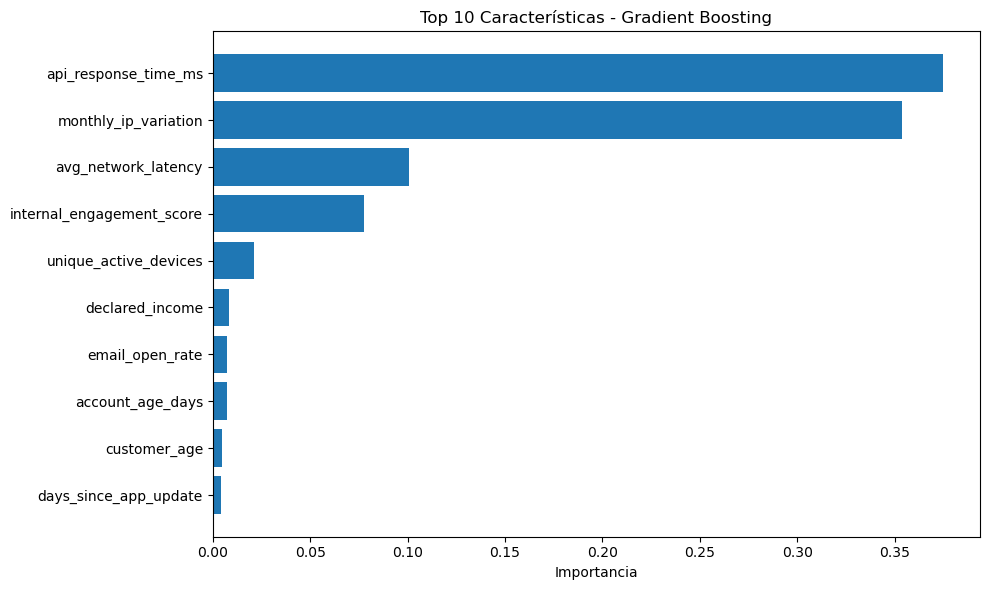

In [32]:
#Validamos el mejor estimador con el conjunto de test
best_gb = grid_gb.best_estimator_
y_pred_gb = best_gb.predict(X_test)

#Mostramos las métricas de evaluación
print("Evaluación en test:")
print(classification_report(y_test, y_pred_gb, target_names=['Renovar', 'Pausar', 'Cancelar']))

# 4. Gráfico de importancia de características
importances = best_gb.feature_importances_
feature_names = X_train.columns

# Ordenar de mayor a menor importancia
indices = np.argsort(importances)[::-1]

print("TOP 10 características más importantes en Boosting")
for i in range(10):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

# Gráfico
plt.figure(figsize=(10, 6))
plt.barh(range(10), importances[indices[:10]][::-1])
plt.yticks(range(10), [feature_names[i] for i in indices[:10]][::-1])
plt.xlabel('Importancia')
plt.title('Top 10 Características - Gradient Boosting')
plt.tight_layout()
plt.show()

<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones y Análisis Crítico:</h4>  

* Vemos que en este caso usando Boosting tenemos un accuracy y un recall general también alto (0.89  y 0.85 respectivamente como en bagging), pero un recall mayor para la clase cancelaciones que en bagging (0.8) aunque sigue siendo menor que en la regresión logística que era de 0.83.
* Las características más importantes se vuelven aquí aún más importantes y se distancian de las demás por el uso de los árboles secuencialmente en el boosting que van corrigiendose, considerando por tanto este modelo que la relevancia de las primeras es mucho mayor que en el bagging, siendo de nuevo api_response_time_ms la mayor con 0.3750, seguida de monthly_ip_variation con 0.3539; con mucha distancia apatecen avg_network_latency (0.1009), internal_engagement_score (0.0775) y unique_active_devices (0.021) y el resto es menor que 0.01. 

</div>

## 5 . Combinación secuencial de clasificadores de base diferente: Stacking

In [22]:
# Definimos los modelos base (del apartado 2)
base_learners = [
    ('logistic', LogisticRegression(random_state=42, max_iter=1000)),
    ('decision_tree', DecisionTreeClassifier(random_state=42)),
    ('knn', KNeighborsClassifier()),
    ('naive_bayes', GaussianNB())
]

#Definimos el meta-clasificador (Regresión Logística con hiperparámetros por defecto)
meta_classifier = LogisticRegression(random_state=42, max_iter=1000)

# Se crea el Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_classifier,
    cv=5  # validación cruzada para entrenar el meta-clasificador
)

#Lo entrenamos el modelo
stacking_clf.fit(X_train, y_train)

#Predecimos
y_pred_stack = stacking_clf.predict(X_test)

#Resultados
print("Resultados del Stacking:")
print(classification_report(y_test, y_pred_stack, target_names=['Renovar', 'Pausar', 'Cancelar']))

Resultados del Stacking:
              precision    recall  f1-score   support

     Renovar       0.91      0.94      0.93       355
      Pausar       0.81      0.78      0.79       185
    Cancelar       0.82      0.75      0.78        60

    accuracy                           0.87       600
   macro avg       0.85      0.82      0.83       600
weighted avg       0.87      0.87      0.87       600



<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones y Análisis Crítico:</h4>  

* El stacking ha combinado los cuatro modelos base del apartado 2 (regresión logística, árbol de decisión, KNN y Naïve Bayes) y hemos usado una regresión logística como meta-clasificador. El resultado no ha sido muy bueno para la métrica de recall de la clase cancelar, ya que ha sido de 0.75, peor que el 0.83 de la regresión logística que era el mejor modelo base y peor que el bagging y boosting. El accuracy se mantiene en 0.87. Esto indica que incluir modelos que funcionaban mal individualmente (como Naïve Bayes con recall 0.67 y KNN con 0.53) ha empeorado la predicción final y el meta-clasificador no ha podido compensar las malas predicciones de estos modelos base. Por lo tanto, el uso de estos modelos a pesar de ser diversa no ha sido buena idea para hacer stacking y no ha aportado ninguna mejora en este dataset.

</div>

## 6 . Combinación secuencial de clasificadores de base diferente: Cascading

In [23]:
#Creamos el Cascading Classifier (base_learners y meta_classifier igual que en stacking)
cascading_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_classifier,
    cv=5,
    passthrough=True #para hacer cascading
)

#Entrenamos el modelo 
cascading_clf.fit(X_train, y_train)
#Predecimos
y_pred_cascading = cascading_clf.predict(X_test)

# REsultados 
print("RESULTADOS DEL CASCADING (passthrough=True)")
print(classification_report(y_test, y_pred_cascading, target_names=['Renovar', 'Pausar', 'Cancelar']))

RESULTADOS DEL CASCADING (passthrough=True)
              precision    recall  f1-score   support

     Renovar       0.91      0.94      0.93       355
      Pausar       0.81      0.77      0.79       185
    Cancelar       0.84      0.78      0.81        60

    accuracy                           0.87       600
   macro avg       0.85      0.83      0.84       600
weighted avg       0.87      0.87      0.87       600



<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones y Análisis Crítico:</h4>  

* El cascading se ha implementado usando passthrough=True, lo que permite que el meta-clasificador reciba no solo las predicciones de los modelos base sino también los datos originales junto con las predicciones, por lo que tiene más información para hacer mejor predicciones. El problema es que a pesar de tener más información, los modelos que se usan, como ha pasado en stacking, han dado valores muy malos por lo que aunque sí hay algo de mejora con respecto a stacking por el aumento de información que tiene en cascading, obteniendo un recall para cancelar de 0.78, que es mejor que el stacking (0.75), sigue siendo peor que la regresión logística (0.83) y el accuracy no mejora del de stacking (se mantiene en 0.87). Darle más información al meta-clasificador no ha sido suficiente y aplicar este modelo que tiene un gasto mayor en términos de eficiencia computacional no ha dado una mejora relevante comparado con el modelo más simple de regresión logística.


</div>

## 7 . Alternativa: Balanced Random Forest

El BalancedRandomForestClassifier es una variante del algoritmo de ensamble Random Forest diseñada específicamente para abordar problemas de clasificación con clases severamente desbalanceadas sin necesidad de pre-procesamiento externo (como SMOTE).

La diferencia fundamental respecto al Random Forest estándar reside en la etapa de construcción de cada árbol de decisión individual (proceso de bootstrapping):

Submuestreo Dinámico: Para entrenar cada árbol del bosque, el algoritmo genera un subconjunto de datos temporal. En este paso, realiza un submuestreo aleatorio (random undersampling) de la clase mayoritaria para igualar el número de instancias de la clase minoritaria. Como resultado, cada árbol individual se entrena con un dataset perfectamente balanceado (ratio 1:1), aunque el dataset original esté descompensado.

Finalmente, el modelo combina las predicciones de todos los árboles (que han visto diferentes subconjuntos equilibrados de la clase mayoritaria) mediante votación para generar la predicción final.

Ventaja Principal: Permite aprovechar la robustez del bagging (reducción de varianza) mientras mitiga el sesgo hacia la clase mayoritaria de forma nativa, explorando una mayor variedad de datos de la clase mayoritaria a través de los múltiples árboles.

In [24]:
#Creamos el modelo Balanced Random Forest
# Vamos a usar hiperparámetros similares a los mejores de Random Forest obtenidos
balanced_rf = BalancedRandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    max_features='sqrt',
    random_state=42,
    sampling_strategy='auto',  # balancea automáticamente las clases
    replacement=False  # submuestreo sin reemplazo
)

#Entremamos
balanced_rf.fit(X_train, y_train)

#Predecimos
y_pred_balanced = balanced_rf.predict(X_test)

#Resultados
print("Resultados del Balanced random Forest:")
print(classification_report(y_test, y_pred_balanced, target_names=['Renovar', 'Pausar', 'Cancelar']))

Resultados del Balanced random Forest:
              precision    recall  f1-score   support

     Renovar       0.94      0.90      0.92       355
      Pausar       0.76      0.75      0.75       185
    Cancelar       0.67      0.90      0.77        60

    accuracy                           0.85       600
   macro avg       0.79      0.85      0.81       600
weighted avg       0.86      0.85      0.85       600



<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones y Análisis Crítico:</h4>  

* El balanced random forest es una variante que balancea las clases dentro de cada árbol para que la clase minoritaria (cancelar) tenga el mismo peso que la mayoritaria. Los resultados han sido buenos y el recall de la clase cancelar ha subido hasta 0.90, superando claramente a la regresión logística (0.83) y a los otros modelos. Sin embargo, esto ha tenido un coste en la precisión de la clase cancelar ha bajado hasta 0.67 (frente a 0.79 de la regresión logística), lo que significa que genera más falsas alarmas. El accuracy global también ha bajado ligeramente a 0.85 lo que es normal porque principalmente muchos pausar se han predecido como cancelar, lo que a pesar de que baje la precisión del modelo es bueno en nuestro caso en el que lo más importante es predecir bien la clase cancelar para evitarla, por lo que a pesar de que en general el modelo es mas agresivo que inteligente, pero creo que para lo que busca la empresa eso es inteligente en este caso. 

</div>

## 8 . Ajuste del Umbral de Decisión

En CloudSync, perder a un cliente corporativo por problemas de latencia (Clase 2) supone una pérdida estimada de 2.000€ (Customer Lifetime Value). Por otro lado, desplegar una intervención proactiva de soporte técnico VIP (auditoría de red, llamada directa) tiene un coste operativo de solo 50€. Por tanto, es preferible asumir falsas alarmas operativas antes que ignorar a un cliente a punto de cancelar. Por defecto, los modelos multiclase asignan la categoría ganadora basándose en la probabilidad más alta (argmax). Utilizando tu mejor modelo (ej. Gradient Boosting), tu objetivo es alterar la lógica de decisión post-entrenamiento.



In [25]:
#Obtenemos las probabilidades del modelo
prob_gb = best_gb.predict_proba(X_test)
prob_cancelar_gb = prob_gb[:, 2]  # columna 2 es Cancelar

#Probamos umbrales
umbrales = [0.50, 0.48, 0.46, 0.44, 0.42, 0.40, 0.38, 0.36, 0.34, 0.32, 0.30, 
            0.28, 0.26, 0.24, 0.22, 0.20, 0.18, 0.16, 0.14, 0.12, 0.10, 0.08, 0.06, 0.04, 0.02, 0.01]
print("Umbral | Recall Cancelar")
print("-" * 30)

for umbral in umbrales:
    #Predecimos la clase con mayor probabilidad
    y_pred = np.argmax(prob_gb, axis=1)
    #si la probabilidad de cancelar supera el umbral, frozamos clase cancelar
    y_pred[prob_cancelar_gb > umbral] = 2
    #y probamos 
    recall_c2 = recall_score(y_test, y_pred, labels=[2], average='micro')
    if recall_c2 >= 0.95:
        print(f"{umbral:.2f}     | {recall_c2:.4f}")
        mejor_umbral_gb = umbral
        break
    else:
        print(f"{umbral:.2f}     | {recall_c2:.4f}")

# Aplicamos el mejor resultado al modelo 
y_pred_gb_ajustado = np.argmax(prob_gb, axis=1)
y_pred_gb_ajustado[prob_cancelar_gb > mejor_umbral_gb] = 2

print(f"\nUmbral usado para Cancelar: {mejor_umbral_gb:.2f}")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_gb_ajustado, target_names=['Renovar', 'Pausar', 'Cancelar']))

Umbral | Recall Cancelar
------------------------------
0.50     | 0.8000
0.48     | 0.8000
0.46     | 0.8167
0.44     | 0.8500
0.42     | 0.8500
0.40     | 0.8500
0.38     | 0.8833
0.36     | 0.8833
0.34     | 0.8833
0.32     | 0.8833
0.30     | 0.8833
0.28     | 0.8833
0.26     | 0.9000
0.24     | 0.9000
0.22     | 0.9167
0.20     | 0.9167
0.18     | 0.9167
0.16     | 0.9167
0.14     | 0.9167
0.12     | 0.9167
0.10     | 0.9333
0.08     | 0.9333
0.06     | 0.9333
0.04     | 0.9500

Umbral usado para Cancelar: 0.04
Reporte de clasificación:
              precision    recall  f1-score   support

     Renovar       0.94      0.94      0.94       355
      Pausar       0.80      0.54      0.64       185
    Cancelar       0.47      0.95      0.63        60

    accuracy                           0.81       600
   macro avg       0.74      0.81      0.74       600
weighted avg       0.85      0.81      0.82       600



In [26]:
#Obtenemos las probabilidades del modelo
prob_brf = balanced_rf.predict_proba(X_test)
prob_cancelar_brf = prob_brf[:, 2]  # Columna 2 = Cancelar

# Probamos diferentes umbrales
umbrales = [0.50, 0.48, 0.46, 0.44, 0.42, 0.40, 0.38, 0.36, 0.34, 0.32, 0.30, 
            0.28, 0.26, 0.24, 0.22, 0.20, 0.18, 0.16, 0.14, 0.12, 0.10, 0.08, 0.06, 0.04, 0.02, 0.01]
print("Umbral | Recall Cancelar")
print("-" * 30)

for umbral in umbrales:
    #Predecimos la clase con mayor probabilidad
    y_pred = np.argmax(prob_brf, axis=1)
    #si la probabilidad de cancelar supera el umbral, frozamos clase cancelar
    y_pred[prob_cancelar_brf > umbral] = 2
    #y probamos
    recall_c2 = recall_score(y_test, y_pred, labels=[2], average='micro')
    if recall_c2 >= 0.95:
        print(f"{umbral:.2f}     | {recall_c2:.4f}")
        mejor_umbral_brf = umbral
        break
    else:
        print(f"{umbral:.2f}     | {recall_c2:.4f}")

# Aplicamos el mejor resultado al modelo 
y_pred_brf_ajustado = np.argmax(prob_brf, axis=1)
y_pred_brf_ajustado[prob_cancelar_brf > mejor_umbral_brf] = 2

print(f"\nUmbral usado para Cancelar: {mejor_umbral_brf:.2f}")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_brf_ajustado, target_names=['Renovar', 'Pausar', 'Cancelar']))

Umbral | Recall Cancelar
------------------------------
0.50     | 0.9000
0.48     | 0.9000
0.46     | 0.9000
0.44     | 0.9167
0.42     | 0.9167
0.40     | 0.9167
0.38     | 0.9167
0.36     | 0.9167
0.34     | 0.9333
0.32     | 0.9333
0.30     | 0.9333
0.28     | 0.9500

Umbral usado para Cancelar: 0.28
Reporte de clasificación:
              precision    recall  f1-score   support

     Renovar       0.94      0.90      0.92       355
      Pausar       0.75      0.62      0.68       185
    Cancelar       0.52      0.95      0.67        60

    accuracy                           0.81       600
   macro avg       0.74      0.82      0.75       600
weighted avg       0.84      0.81      0.82       600



In [27]:
# Análisis económico de ambos modelos
coste_cliente_perdido = 2000
coste_falsa_alarma = 50

# GRADIENT BOOSTING
# Original
y_pred_gb_original = best_gb.predict(X_test)
fn_gb_original = np.sum((y_test == 2) & (y_pred_gb_original != 2))
fp_gb_original = np.sum((y_test != 2) & (y_pred_gb_original == 2))
coste_gb_original = fn_gb_original * coste_cliente_perdido + fp_gb_original * coste_falsa_alarma

# Ajustado (umbral 0.04)
fn_gb_ajustado = np.sum((y_test == 2) & (y_pred_gb_ajustado != 2))
fp_gb_ajustado = np.sum((y_test != 2) & (y_pred_gb_ajustado == 2))
coste_gb_ajustado = fn_gb_ajustado * coste_cliente_perdido + fp_gb_ajustado * coste_falsa_alarma

print("\nGRADIENT BOOSTING")
print(f"  Coste total ORIGINAL (umbral 0.5): {coste_gb_original} €")
print(f"  Coste total AJUSTADO (umbral 0.04): {coste_gb_ajustado} €")
print(f"  Ahorro: {coste_gb_original - coste_gb_ajustado} €")

# BALANCED RANDOM FOREST
# Original (umbral 0.5)
y_pred_brf_original = balanced_rf.predict(X_test)
fn_brf_original = np.sum((y_test == 2) & (y_pred_brf_original != 2))
fp_brf_original = np.sum((y_test != 2) & (y_pred_brf_original == 2))
coste_brf_original = fn_brf_original * coste_cliente_perdido + fp_brf_original * coste_falsa_alarma

# Ajustado (umbral 0.28)
fn_brf_ajustado = np.sum((y_test == 2) & (y_pred_brf_ajustado != 2))
fp_brf_ajustado = np.sum((y_test != 2) & (y_pred_brf_ajustado == 2))
coste_brf_ajustado = fn_brf_ajustado * coste_cliente_perdido + fp_brf_ajustado * coste_falsa_alarma

print("\nBALANCED RANDOM FOREST")
print(f"  Coste total ORIGINAL (umbral 0.5): {coste_brf_original} €")
print(f"  Coste total AJUSTADO (umbral 0.28): {coste_brf_ajustado} €")
print(f"  Ahorro: {coste_brf_original - coste_brf_ajustado} €")

# COMPARATIVA FINAL
print("\n" + "="*60)
print("COMPARATIVA:")
print(f"\nCoste total con Gradient Boosting (umbral 0.04): {coste_gb_ajustado} €")
print(f"Coste total con Balanced Random Forest (umbral 0.28): {coste_brf_ajustado} €")


GRADIENT BOOSTING
  Coste total ORIGINAL (umbral 0.5): 24550 €
  Coste total AJUSTADO (umbral 0.04): 9250 €
  Ahorro: 15300 €

BALANCED RANDOM FOREST
  Coste total ORIGINAL (umbral 0.5): 13350 €
  Coste total AJUSTADO (umbral 0.28): 8650 €
  Ahorro: 4700 €

COMPARATIVA:

Coste total con Gradient Boosting (umbral 0.04): 9250 €
Coste total con Balanced Random Forest (umbral 0.28): 8650 €


<div style="background-color: #dff0d8; color: #3c763d; padding: 10px; border: 1px solid #d6e9c6; border-radius: 4px;">
<h4>Observaciones y Análisis Crítico:</h4>  

* He probado el análisis con Gradient Boosting porque se recomendaba en el enunciado y también con Balanced random forest que es el modelo que a mi me dio el mejor resultado.
* Con gradient boosting obtenemos que el primer valor que nos devuelve un recal del 95% es el 0.04, que es un valor muy bajo que significa que con una probabilidad del 4% de cancelar el modelo ya lo clasifica como cancelar. Vemos que esto afecta principalmente a la clase pausar, que baja su recall a 0.54, mientras que la clase renovar se mantiene con un recall muy alto, es decir, está siendo bien predecida. El accuracy baja a 0.81 porque estamos prediciendo mal aunque sea a proposito la clase pausar, pero eso es lo que buscamos así que no se debe considerar como malo.
* Con Balanced Random forest es suficiente con una probabilidad mucho mayor para llegar al mismo nivel de recall en Cancelar y alcanza el 0.95 en 0.28, es decir, cuando el modelo predice que tiene una probabilidad del 28% de cancelar, lo clasifica como cancelar. El recall general es poco más alto (0.82) que el de gradient boosting, y observamos que lo que clasifica mejor que el anterior es la probabilidad de pausar con un 0,62 aunque pierde un poco en la de renovar (pasa de 0.94 a 0.90). El accuracy se mantiene igual en 0.81.
* Para el análisis económico hemos comparado ambos modelos, tanto en el coste que nos daba antes de aplicar el ajuste del umbral de decisión como después. En ambos se ha disminuido el coste considerablemente. En gradient boosting hemos pasado de 24550€ en el original a 9250€ en el  modelo ajustado y en Balanced random forest hemos pasado de 13350€ (el original era menor) a 8650€. Por lo que concluimos que económicamente es más rentable el modelo ajustado de balanced random forest, aunque solo por 600€ de diferencia.

</div>